In [22]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

In [23]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import root_mean_squared_error

In [24]:
import os
cwd = os.getcwd()
parent = os.path.dirname(cwd)

train = pd.read_csv(os.path.join(parent, 'train.csv'))
train.index = train['id'].values
train.drop('id', axis=1, inplace=True)

hour0 = "2023-01-01 00:00:00"
hour0 = pd.to_datetime(hour0)
hour0 = hour0
train['delivery_start'] = pd.to_datetime(train['delivery_start'])
train['delivery_end'] = pd.to_datetime(train['delivery_end'])
train['delivery_start'] = (train['delivery_start'] - hour0).dt.total_seconds() / 3600
train['delivery_end'] = (train['delivery_end'] - hour0).dt.total_seconds() / 3600

train['market'] = train['market'].map({'Market A': 0, 'Market B': 1, 'Market C': 2, 'Market D': 3, 'Market E': 4, 'Market F': 5})
clean_train = train.dropna()

Data = clean_train.copy()

In [25]:
Y = Data['target']
X = Data.drop(['target'], axis=1)
X = pd.DataFrame(
    StandardScaler(
    with_mean=True,
    with_std=True
    ).fit_transform(X)
)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)


In [26]:
results, accuracy = [], []
for K in range(1,50):
    knn = KNeighborsRegressor(n_neighbors=K)
    model = knn.fit(X_train, y_train)
    results.append(model)
    accuracy.append(root_mean_squared_error(y_test, model.predict(X_test)))

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

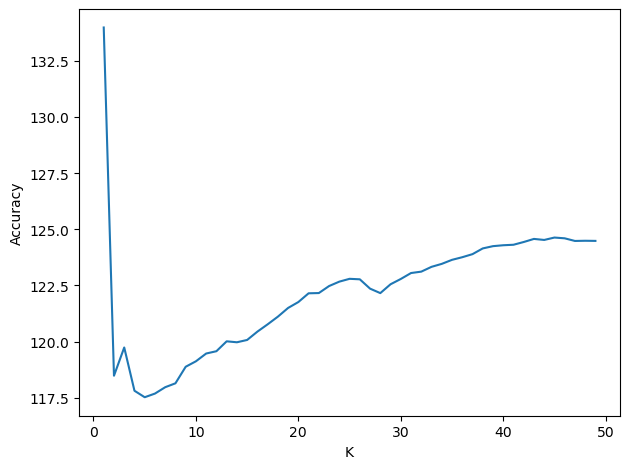

In [29]:
plt.plot(range(1,50), accuracy)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('Plots\\KNN_RMSE.png')

In [ ]:
k_best = accuracy.index(max(accuracy))
print('Best K:', k_best)
print('RMSE:', accuracy[k_best])

Best K: 46
Accuracy: 0.8415


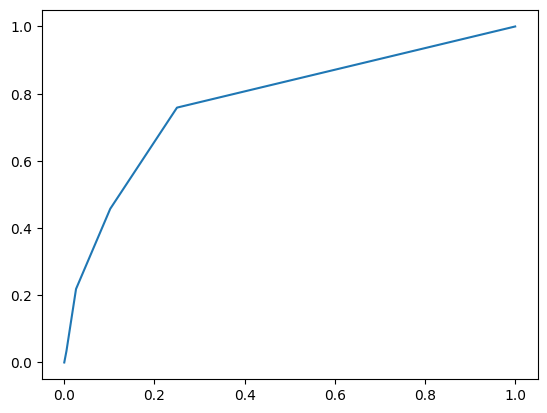

In [ ]:
sensitivity, specificity1, thresholds = roc_curve(y_test, results[3].predict_proba(X_test)[:,1])
plt.plot(sensitivity, specificity1);